In [1]:
# Google Colab / local setup
import os, sys, subprocess
from pathlib import Path
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    CODE_ROOT = Path("/content/drive/MyDrive/msc project/code")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e",
        str(CODE_ROOT), 'catboost==1.2.10', 'rapidfuzz==3.14.3',
    ])
else:
    CODE_ROOT = next(
        path for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").exists()
    )
os.chdir(CODE_ROOT)
sys.path.insert(0, str(CODE_ROOT))
CODE = CODE_ROOT

# 01 — BTC data, labels and baseline

BTCUSDT M15 data from January 2024 to June 2025 are used for an exploratory CatBoost baseline with short/flat/long labels, five blocked time-series folds and 10 bps round-trip costs.

The comparison tests dead-zone widths and funding/open-interest features; later notebooks use the registered 2024 selection, H1-2025 calibration and July-2025–March-2026 forward protocol.
Q2-2026 is evaluated separately in Notebook 07.

In [2]:
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

from features.build import build_dataset, FEATURE_COLS
from evaluation.splits import BlockingTimeSeriesSplit
from evaluation.metrics import classification_scores, report_text, CLASS_NAMES
from models.zoo import make_catboost, run_cv, MODELS

cfg = yaml.safe_load((CODE_ROOT / "configs" / "default.yaml").read_text())
# DZ40 is the illustrative classification reference.
THRESHOLD_BPS = 40
SPLIT = cfg["split"]
print("config:", cfg["instrument"], cfg["target_interval"],
      "| chosen dead-zone:", THRESHOLD_BPS, "bps | split:", SPLIT)
from experiments.notebook02_handoff import NOTEBOOK01_WIDTHS, PIPELINE_HANDOFF, WIDTHS, write_notebook01_handoff, write_pipeline_handoff

config: BTCUSDT 15min | chosen dead-zone: 40 bps | split: {'n_splits': 5, 'train_frac': 0.8, 'embargo_bars': 4}


## 1. Market data

Native Binance M15 candles supply OHLCV, taker-buy volume and trade counts; this baseline uses January 2024–June 2025 only.

In [3]:
working = pd.read_parquet(CODE_ROOT / cfg["paths"]["working_parquet"])
df = working.loc["2024-01-01":"2025-06-30"]   # development window: 2024 + 2025-H1
print(f"dev-window M15 bars: {len(df):,}  ({df.index[0]} -> {df.index[-1]})")


dev-window M15 bars: 52,512  (2024-01-01 00:00:00+00:00 -> 2025-06-30 23:45:00+00:00)


## 2. Features and labels

Price, volatility, volume, time and order-flow features use information available at each bar close; the next-M15 return defines SHORT below minus the dead zone, LONG above plus the dead zone, and FLAT otherwise.

In [4]:
X, y = build_dataset(df, threshold_bps=THRESHOLD_BPS, horizon=1)
print(f"X: {X.shape}   y: {y.shape}")
print("features:", list(X.columns))


X: (52451, 17)   y: (52451,)
features: ['r1', 'r5', 'r20', 'vol_10', 'vol_20', 'vol_60', 'hl_range', 'co_range', 'rsi_14', 'volume', 'vol_z', 'hour', 'dayofweek', 'ofi', 'ofi_z20', 'ofi_mom5', 'trade_intensity_z']


## 3. Class balance

The dead zone is the minimum absolute next-bar return labelled directional; wider zones increase the flat share.

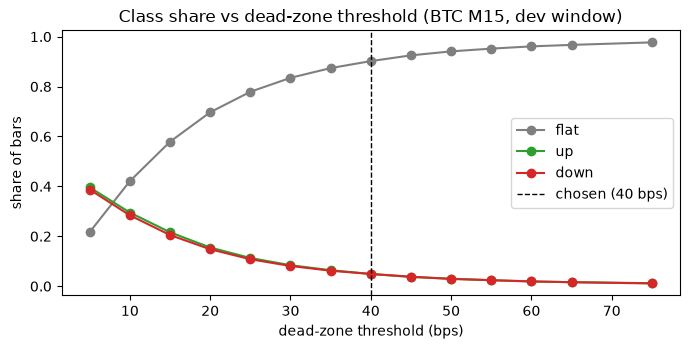

Method: Class shares are counted on the same development bars at each dead-zone width.

,down,flat,up
threshold_bps,,,
5,0.387,0.217,0.396
10,0.284,0.421,0.295
15,0.205,0.579,0.216
20,0.148,0.697,0.155
25,0.108,0.779,0.113
30,0.081,0.835,0.084
35,0.062,0.874,0.064
40,0.049,0.902,0.049
45,0.038,0.925,0.037


Wider dead zones make directional labels progressively rarer.

In [5]:
from IPython.display import Markdown
rows = []
for thr in [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 75]:
    _, ys = build_dataset(df, threshold_bps=thr, horizon=1)
    vc = ys.value_counts(normalize=True)
    rows.append({"threshold_bps": thr,
                 "down": vc.get(0, 0), "flat": vc.get(1, 0), "up": vc.get(2, 0)})
sweep = pd.DataFrame(rows).set_index("threshold_bps").round(3)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(sweep.index, sweep["flat"], marker="o", color="#7f7f7f", label="flat")
ax.plot(sweep.index, sweep["up"], marker="o", color="#2ca02c", label="up")
ax.plot(sweep.index, sweep["down"], marker="o", color="#d62728", label="down")
ax.axvline(THRESHOLD_BPS, color="black", ls="--", lw=1,
           label=f"chosen ({THRESHOLD_BPS} bps)")
ax.set_xlabel("dead-zone threshold (bps)"); ax.set_ylabel("share of bars")
ax.set_title("Class share vs dead-zone threshold (BTC M15, dev window)")
ax.legend(); plt.tight_layout(); plt.show()

display(Markdown('Method: Class shares are counted on the same development bars at each dead-zone width.'))
display(sweep)
display(Markdown('Wider dead zones make directional labels progressively rarer.'))

## 4. Time-series split

Five disjoint chronological blocks each contain an 80% training segment, a four-bar embargo and a later test segment; non-overlap does not imply statistical independence.

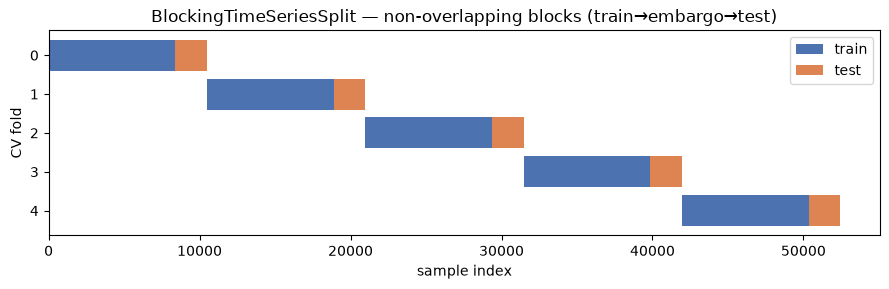

In [6]:
splitter = BlockingTimeSeriesSplit(
    n_splits=SPLIT["n_splits"], train_frac=SPLIT["train_frac"], embargo=SPLIT["embargo_bars"])

fig, ax = plt.subplots(figsize=(9, 3))
for i, (tr, te) in enumerate(splitter.split(X)):
    ax.barh(i, len(tr), left=tr[0], color="#4c72b0", label="train" if i == 0 else "")
    ax.barh(i, len(te), left=te[0], color="#dd8452", label="test" if i == 0 else "")
ax.set_xlabel("sample index"); ax.set_ylabel("CV fold")
ax.set_yticks(range(splitter.n_splits))
ax.invert_yaxis(); ax.legend(loc="upper right")
ax.set_title("BlockingTimeSeriesSplit — non-overlapping blocks (train→embargo→test)")
plt.tight_layout(); plt.show()

## 5. Classification

CatBoost balances classes during training only; test labels retain their observed proportions, and macro-F1 is reported alongside balanced accuracy and the always-flat control.

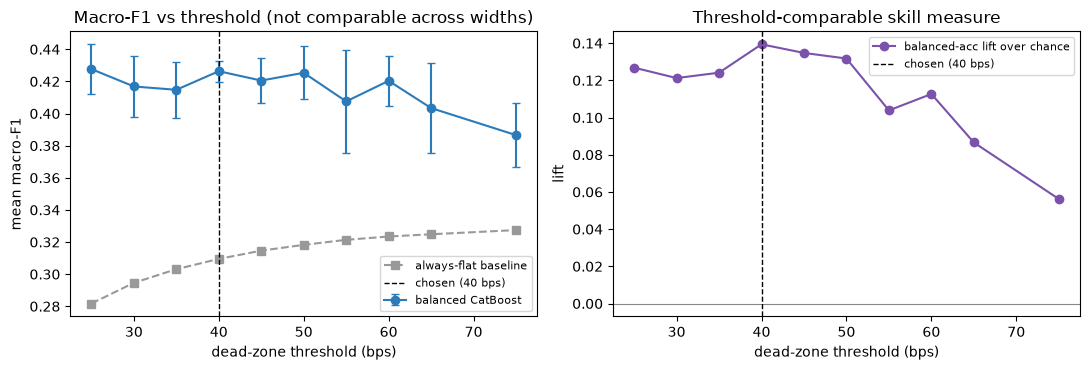

Method: Balanced CatBoost and always-flat predictions are compared on identical five-fold tests for each width.

,flat share,CatBoost macro-F1,always-flat F1,balanced acc,bal-acc lift vs chance
dead-zone (bps),,,,,
25,77.9%,0.428 ± 0.015,0.282,0.460,+0.127
30,83.5%,0.417 ± 0.019,0.295,0.455,+0.121
35,87.4%,0.415 ± 0.017,0.303,0.457,+0.124
40,90.2%,0.426 ± 0.006,0.309,0.473,+0.139
45,92.5%,0.421 ± 0.014,0.315,0.468,+0.135
50,94.1%,0.425 ± 0.016,0.318,0.465,+0.132
55,95.2%,0.408 ± 0.032,0.321,0.437,+0.104
60,96.1%,0.420 ± 0.016,0.323,0.446,+0.113
65,96.7%,0.403 ± 0.028,0.325,0.420,+0.087


Classification skill exceeds the trivial control, but does not imply profitable trading.

In [7]:
from IPython.display import Markdown
THRS = [25, 30, 35, 40, 45, 50, 55, 60, 65, 75]
thr_rows = []
for thr in THRS:
    Xt, yt = build_dataset(df, threshold_bps=thr, horizon=1)
    rc = run_cv(MODELS["catboost_balanced"], Xt, yt, splitter)
    rf = run_cv(MODELS["always_flat"], Xt, yt, splitter)
    thr_rows.append({
        "threshold_bps": thr,
        "flat_share": yt.value_counts(normalize=True).get(1, 0.0),
        "catboost_f1": rc["mean_macro_f1"], "catboost_f1_std": rc["std_macro_f1"],
        "always_flat_f1": rf["mean_macro_f1"],
        "lift_over_flat": rc["mean_macro_f1"] - rf["mean_macro_f1"],
        "balanced_acc": rc["mean_balanced_accuracy"],
    })
thr_res = pd.DataFrame(thr_rows).set_index("threshold_bps")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axes[0]
ax.errorbar(thr_res.index, thr_res["catboost_f1"], yerr=thr_res["catboost_f1_std"],
            marker="o", capsize=3, label="balanced CatBoost", color="#2b7bba")
ax.plot(thr_res.index, thr_res["always_flat_f1"], marker="s", ls="--",
        color="#999", label="always-flat baseline")
ax.axvline(THRESHOLD_BPS, color="black", ls="--", lw=1, label=f"chosen ({THRESHOLD_BPS} bps)")
ax.set_xlabel("dead-zone threshold (bps)"); ax.set_ylabel("mean macro-F1")
ax.set_title("Macro-F1 vs threshold (not comparable across widths)")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(thr_res.index, thr_res["balanced_acc"] - 1 / 3, marker="o", color="#7b52ab",
        label="balanced-acc lift over chance")
ax.axhline(0, color="#888", lw=0.8)
ax.axvline(THRESHOLD_BPS, color="black", ls="--", lw=1, label=f"chosen ({THRESHOLD_BPS} bps)")
ax.set_xlabel("dead-zone threshold (bps)"); ax.set_ylabel("lift")
ax.set_title("Threshold-comparable skill measure")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Presentation table: readable headers + formatted units. macro-F1 columns are NOT
# comparable across rows (the always-flat baseline moves with the flat share); the
# balanced-accuracy lift is the threshold-comparable skill measure.
results_table = pd.DataFrame({
    "flat share": thr_res["flat_share"].map("{:.1%}".format),
    "CatBoost macro-F1": [f"{m:.3f} ± {s:.3f}"
                          for m, s in zip(thr_res["catboost_f1"], thr_res["catboost_f1_std"])],
    "always-flat F1": thr_res["always_flat_f1"].map("{:.3f}".format),
    "balanced acc": thr_res["balanced_acc"].map("{:.3f}".format),
    "bal-acc lift vs chance": (thr_res["balanced_acc"] - 1 / 3).map("{:+.3f}".format),
})
results_table.index.name = "dead-zone (bps)"
display(Markdown('Method: Balanced CatBoost and always-flat predictions are compared on identical five-fold tests for each width.'))
display(results_table)
display(Markdown('Classification skill exceeds the trivial control, but does not imply profitable trading.'))

### Ungated economics

These one-bar predictions are diagnostic trades, not a calibrated strategy.

In [8]:
from IPython.display import Markdown
# Out-of-fold economics per dead-zone width. run_cv keeps no per-row predictions, so
# the folds are re-fit with the same splitter and the held-out predictions pooled.
from evaluation.economics import strategy_returns, economics_summary

FEE_BPS = float(cfg["taker_fee_bps"])
fwd_all = df["close"].pct_change().shift(-1)   # next-bar return, aligned to signal bar

def oof_catboost(Xt, yt):
    """Pooled held-out-fold predictions across blocking CV folds."""
    pred = pd.Series(np.nan, index=Xt.index)
    for tr, te in splitter.split(Xt):
        model = MODELS["catboost_balanced"](None)
        model.fit(Xt.iloc[tr], yt.iloc[tr])
        p = np.asarray(model.predict(Xt.iloc[te])).ravel().astype(int)
        pred.iloc[te] = p
    return pred.dropna().astype(int)

econ_rows = []
for thr in THRS:
    Xt, yt = build_dataset(df, threshold_bps=thr, horizon=1)
    pred = oof_catboost(Xt, yt)
    ret = strategy_returns(pred, fwd_all.reindex(pred.index), FEE_BPS)
    s = economics_summary(ret, pred)
    econ_rows.append({"threshold_bps": thr, "sortino": s["sortino"],
                      "sharpe": s["sharpe"], "net_return": s["net_return_sum"],
                      "trades": int(s["trade_count"])});

econ = pd.DataFrame(econ_rows).set_index("threshold_bps")
BEST_THR = int(econ["sortino"].idxmax())
display(Markdown('Method: Each held-out directional prediction is scored over one bar after 5 bps per side.'))
display(econ.round(4))
display(Markdown('Every ungated width has negative net return.'))

Method: Each held-out directional prediction is scored over one bar after 5 bps per side.

,sortino,sharpe,net_return,trades
threshold_bps,,,,
25,-16.8593,-12.8946,-2.1224,3189
30,-16.4673,-12.6129,-1.9971,2910
35,-14.4667,-11.2003,-1.7040,2468
40,-13.1580,-10.1946,-1.4712,2182
45,-11.2075,-8.5917,-1.1849,1955
50,-6.8871,-5.1673,-0.6494,1594
55,-8.8255,-6.7151,-0.7928,1359
60,-4.6762,-3.4834,-0.3785,1069
65,-6.0945,-4.7007,-0.4627,824


Every ungated width has negative net return.

## 6. Funding and open interest

Binance futures funding, open interest and long/short ratios are joined backward as-of M15 closes; the two arms use identical complete rows and folds, which differ from the full-sample comparison above.

In [9]:
from IPython.display import Markdown
# Paired re-test: price+order-flow vs price+order-flow+positioning, same rows/folds.
pos = pd.read_parquet(CODE_ROOT / "data" / "btcusdt_positioning_m15_2024_2026.parquet")
dfp = df.join(pos.reindex(df.index))          # positioning columns onto the dev bars

def oof_scores(Xt, yt):
    """One CV pass -> pooled OOF preds + mean/std fold scores."""
    pred = pd.Series(np.nan, index=Xt.index)
    f1s, bals = [], []
    for tr, te in splitter.split(Xt):
        model = MODELS["catboost_balanced"](None)
        model.fit(Xt.iloc[tr], yt.iloc[tr])
        p = np.asarray(model.predict(Xt.iloc[te])).ravel().astype(int)
        pred.iloc[te] = p
        s = classification_scores(yt.iloc[te], p)
        f1s.append(s["macro_f1"]); bals.append(s["balanced_accuracy"])
    return (pred.dropna().astype(int), float(np.mean(f1s)), float(np.std(f1s)),
            float(np.mean(bals)))

pos_rows = []
for thr in THRS:
    Xb, yb = build_dataset(dfp, threshold_bps=thr, horizon=1)                    # base
    Xp, yp = build_dataset(dfp, threshold_bps=thr, horizon=1, positioning=True)  # +pos
    common = Xb.index.intersection(Xp.index)          # identical rows for both runs
    Xb, yb = Xb.loc[common], yb.loc[common]
    Xp, yp = Xp.loc[common], yp.loc[common]
    pb, f1b, sb, balb = oof_scores(Xb, yb)
    pp, f1p, sp, balp = oof_scores(Xp, yp)
    fwd = fwd_all.reindex(common)
    nb = economics_summary(strategy_returns(pb, fwd.reindex(pb.index), FEE_BPS), pb)
    np_ = economics_summary(strategy_returns(pp, fwd.reindex(pp.index), FEE_BPS), pp)
    pos_rows.append({
        "threshold_bps": thr, "n_rows": len(common),
        "f1_base": f1b, "f1_base_std": sb, "f1_pos": f1p, "f1_pos_std": sp,
        "bal_base": balb, "bal_pos": balp,
        "sortino_base": nb["sortino"], "sortino_pos": np_["sortino"],
        "sharpe_base": nb["sharpe"], "sharpe_pos": np_["sharpe"],
        "net_base": nb["net_return_sum"], "net_pos": np_["net_return_sum"],
        "trades_base": int(nb["trade_count"]), "trades_pos": int(np_["trade_count"]),
    })

posr = pd.DataFrame(pos_rows).set_index("threshold_bps")
# per-trade expectancy (bps) isolates edge from volume: a lower loss on fewer
# trades is prudence, not skill; a higher per-trade return is a real edge.
posr["exp_base"] = posr["net_base"] / posr["trades_base"].clip(lower=1) * 1e4
posr["exp_pos"] = posr["net_pos"] / posr["trades_pos"].clip(lower=1) * 1e4
pos_table = pd.DataFrame({
    "Δ F1": (posr["f1_pos"] - posr["f1_base"]).map("{:+.3f}".format),
    "Δ bal-acc": (posr["bal_pos"] - posr["bal_base"]).map("{:+.3f}".format),
    "Sortino (base)": posr["sortino_base"].map("{:+.2f}".format),
    "Sortino (+pos)": posr["sortino_pos"].map("{:+.2f}".format),
    "Sharpe (base)": posr["sharpe_base"].map("{:+.2f}".format),
    "Sharpe (+pos)": posr["sharpe_pos"].map("{:+.2f}".format),
    "net (base)": posr["net_base"].map("{:+.3f}".format),
    "net (+pos)": posr["net_pos"].map("{:+.3f}".format),
    "Δ net": (posr["net_pos"] - posr["net_base"]).map("{:+.3f}".format),
    "trades base→+pos": [f"{b:,}→{p:,}" for b, p in zip(posr["trades_base"], posr["trades_pos"])],
    "exp/trade base (bps)": posr["exp_base"].map("{:+.1f}".format),
    "exp/trade +pos (bps)": posr["exp_pos"].map("{:+.1f}".format),
})
pos_table.index.name = "dead-zone (bps)"
display(Markdown('Method: Both feature arms use identical positioning-complete rows, blocked folds and 10 bps round-trip costs.'))
display(pos_table)
display(Markdown('Positioning reduces losses mainly alongside fewer trades.'))

Method: Both feature arms use identical positioning-complete rows, blocked folds and 10 bps round-trip costs.

,Δ F1,Δ bal-acc,Sortino (base),Sortino (+pos),Sharpe (base),Sharpe (+pos),net (base),net (+pos),Δ net,trades base→+pos,exp/trade base (bps),exp/trade +pos (bps)
dead-zone (bps),,,,,,,,,,,,
25,+0.008,+0.005,-15.99,-13.46,-12.20,-10.15,-2.036,-1.646,+0.390,"3,142→2,926",-6.5,-5.6
30,+0.012,+0.006,-14.13,-9.76,-10.75,-7.18,-1.730,-1.107,+0.624,"2,855→2,638",-6.1,-4.2
35,+0.006,-0.001,-13.63,-11.55,-10.44,-8.60,-1.583,-1.275,+0.308,"2,513→2,328",-6.3,-5.5
40,+0.006,-0.008,-9.81,-7.37,-7.35,-5.40,-1.061,-0.750,+0.311,"2,216→1,913",-4.8,-3.9
45,+0.008,-0.010,-12.32,-7.05,-9.46,-5.16,-1.288,-0.636,+0.652,"1,947→1,507",-6.6,-4.2
50,+0.005,-0.010,-8.91,-5.22,-6.85,-3.89,-0.860,-0.449,+0.410,"1,551→1,210",-5.5,-3.7
55,-0.004,-0.021,-10.36,-4.49,-7.95,-3.25,-0.912,-0.321,+0.591,"1,323→878",-6.9,-3.7
60,-0.015,-0.025,-10.83,-5.70,-8.64,-4.35,-0.904,-0.390,+0.515,"1,041→716",-8.7,-5.4
65,-0.009,-0.020,-7.57,-2.29,-5.96,-1.64,-0.568,-0.115,+0.453,848→480,-6.7,-2.4


Positioning reduces losses mainly alongside fewer trades.

Positioning reduces losses on the shared sample, but does not establish positive net performance.

### Registered downstream widths

DZ55, DZ65 and DZ75, 24 market features and 180-day training histories are fixed for the downstream comparison; reruns do not reselect them.

In [10]:
from IPython.display import Markdown
# Report the widths frozen by the original development run; never reselect on a rerun.
selected_widths = posr.loc[sorted(WIDTHS, reverse=True)].copy()
handoff_rows = pd.DataFrame({
    "width_bps": selected_widths.index.astype(int),
    "sortino": selected_widths["sortino_pos"].astype(float).to_numpy(),
    "sharpe": selected_widths["sharpe_pos"].astype(float).to_numpy(),
    "net_return": selected_widths["net_pos"].astype(float).to_numpy(),
    "trades": selected_widths["trades_pos"].astype(int).to_numpy(),
})
write_notebook01_handoff(handoff_rows, NOTEBOOK01_WIDTHS)
write_pipeline_handoff(upstream=handoff_rows, path=PIPELINE_HANDOFF)
width_table = pd.DataFrame({
    "dead zone": handoff_rows["width_bps"].map(lambda value: f"DZ{value}"),
    "Sortino": handoff_rows["sortino"].map("{:+.2f}".format),
    "Sharpe": handoff_rows["sharpe"].map("{:+.2f}".format),
    "net after costs": handoff_rows["net_return"].map("{:+.1%}".format),
    "events": handoff_rows["trades"].map("{:,}".format),
})
display(Markdown('Method: The table reports the three registered downstream widths without reranking them.'))
display(width_table.set_index("dead zone"))
display(Markdown('DZ55, DZ65 and DZ75 remain the fixed downstream candidates.'))

Method: The table reports the three registered downstream widths without reranking them.

,Sortino,Sharpe,net after costs,events
dead zone,,,,
DZ75,-1.97,-1.45,-7.7%,267
DZ65,-2.29,-1.64,-11.5%,480
DZ55,-4.49,-3.25,-32.1%,878


DZ55, DZ65 and DZ75 remain the fixed downstream candidates.

These widths define the downstream experiment, not a profitability claim.

## 7. Shuffled-label check

The same pipeline is fitted to permuted labels as a sanity check; reduced macro-F1 is reassuring but cannot prove the absence of leakage, and its null level depends on class prevalence.

In [11]:
rng = np.random.default_rng(0)
y_shuffled = pd.Series(rng.permutation(y.values), index=y.index, name="label")
shuffled = run_cv(lambda p=None: make_catboost({"iterations": 120}), X, y_shuffled, splitter)
real_f1 = thr_res.loc[THRESHOLD_BPS, "catboost_f1"]   # section-5 sweep @ chosen width
print(f"shuffled-label macro-F1: {shuffled['mean_macro_f1']:.3f}")
print(f"real-label   macro-F1: {real_f1:.3f}  (@ {THRESHOLD_BPS} bps)")
assert shuffled["mean_macro_f1"] < 0.40, "LEAK: shuffled-label score too high"
print("Shuffled-label sanity check passed; this is not a proof of no leakage.")

shuffled-label macro-F1: 0.296
real-label   macro-F1: 0.426  (@ 40 bps)
Shuffled-label sanity check passed; this is not a proof of no leakage.


## Conclusion

Positioning improves the ungated control, but net returns remain negative; the registered DZ55/DZ65/DZ75 candidates continue to the matched tuning and sentiment comparisons.

## Data sources

The table identifies the input frequency and its role; all joins use information available by the decision time.

| Source | Frequency | Role |
|---|---|---|
| Binance spot candles | 15 minutes | BTC features and next-bar labels |
| Binance spot candles | 1 minute | Execution paths; not model features |
| Binance futures metrics and funding | 5-minute snapshots / funding events | Funding, open interest and positioning |
| GDELT GKG through BigQuery | Timestamped English approved-source news | Sentiment from Notebook 02c |
| Dukascopy/JForex Bid/Ask exports | 1 minute | Separate USA500, USATECH and volatility-index experiments |

Different source frequencies serve prediction, execution and supplementary features; 1-minute bars do not reveal the order of touches within a minute.